# Gray–Scott · (f, k) phase diagram

Exploratory analysis of The Well `gray_scott_reaction_diffusion` feature table.

**Not ANOVA** — focus on the feed–kill phase map, regime summary tables, and pattern metrics vs parameters.


In [1]:
from pathlib import Path
import sys
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#5F6B45", "#9A7340", "#3D5A56", "#7A3E32", "#5C574E", "#8A9470"]
sns.set_palette(PALETTE)
%matplotlib inline

from src.dataset_catalog import get_dataset

spec = get_dataset("gray_scott")
df = pd.read_parquet(spec.feature_path)
print("rows:", len(df), "| synthetic:", bool(df["synthetic"].any()) if "synthetic" in df.columns else "n/a")
print("regimes:", sorted(df["pattern"].unique()))
df.head()


rows: 16 | synthetic: False
regimes: ['Bubbles', 'Gliders', 'Maze', 'Spirals', 'Spots', 'Worms']


,split,file,traj_idx,replicate,f,k,pattern,mean_A,mean_B,std_A,std_B,pattern_contrast,spectral_slope,time_to_steady,n_timesteps_used,spatial_resolution_used,synthetic,injected_anomaly
0,train,gray_scott_reaction_diffusion_bubbles_F_0.098_...,0,0,0.098,0.057,Bubbles,0.973254,0.014708,0.091218,0.064077,0.155295,0.558401,0.129032,32,16,False,False
1,train,gray_scott_reaction_diffusion_bubbles_F_0.098_...,1,1,0.098,0.057,Bubbles,0.939544,0.041297,0.155832,0.117099,0.272932,0.890571,0.129032,32,16,False,False
2,train,gray_scott_reaction_diffusion_gliders_F_0.014_...,0,0,0.014,0.054,Gliders,0.785671,0.045523,0.199733,0.079581,0.279314,-1.501286,0.935484,32,16,False,False
3,train,gray_scott_reaction_diffusion_gliders_F_0.014_...,1,1,0.014,0.054,Gliders,0.782752,0.045527,0.199832,0.080468,0.280300,-1.641199,1.000000,32,16,False,False
4,train,gray_scott_reaction_diffusion_maze_F_0.029_k_0...,0,0,0.029,0.057,Maze,0.546630,0.152575,0.182398,0.104440,0.286838,-1.538186,0.161290,32,16,False,False


## Coverage table

How many trajectories sit in each named (f, k) regime.

In [2]:

coverage = (
    df.groupby(["pattern", "f", "k"], as_index=False)
    .size()
    .rename(columns={"size": "n_traj"})
    .sort_values(["f", "k"])
)
display(coverage)
print(f"Total trajectories: {coverage['n_traj'].sum()} | regimes: {len(coverage)}")


,pattern,f,k,n_traj
1,Gliders,0.014,0.054,2
3,Spirals,0.018,0.051,3
2,Maze,0.029,0.057,3
4,Spots,0.030,0.062,3
5,Worms,0.058,0.065,3
0,Bubbles,0.098,0.057,2


Total trajectories: 16 | regimes: 6


## Feature dictionary (this table)

In [3]:

desc = {
    "f": "feed rate",
    "k": "kill rate",
    "pattern": "named regime label",
    "mean_A / mean_B": "time–space mean concentrations",
    "std_A / std_B": "spatial/temporal variability",
    "pattern_contrast": "std_A + std_B (pattern strength proxy)",
    "spectral_slope": "log–log spectral slope of A",
    "time_to_steady": "fraction of run until A plateaus",
}
pd.DataFrame({"column / group": list(desc), "meaning": list(desc.values())})


,column / group,meaning
0,f,feed rate
1,k,kill rate
2,pattern,named regime label
3,mean_A / mean_B,time–space mean concentrations
4,std_A / std_B,spatial/temporal variability
5,pattern_contrast,std_A + std_B (pattern strength proxy)
6,spectral_slope,log–log spectral slope of A
7,time_to_steady,fraction of run until A plateaus


## Summary statistics by regime

In [4]:

metrics = [c for c in [
    "pattern_contrast", "mean_A", "mean_B", "std_A", "std_B",
    "spectral_slope", "time_to_steady",
] if c in df.columns]

summary = (
    df.groupby("pattern")[metrics]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
display(summary)

# Compact mean-only table for readability
means = df.groupby("pattern")[metrics].mean().round(4).sort_values("pattern_contrast")
display(means)


pattern_contrast                          mean_A                  \
                    mean     std     min     max    mean     std     min   
pattern                                                                    
Bubbles           0.2141  0.0832  0.1553  0.2729  0.9564  0.0238  0.9395   
Gliders           0.2798  0.0007  0.2793  0.2803  0.7842  0.0021  0.7828   
Maze              0.2717  0.0131  0.2632  0.2868  0.5358  0.0199  0.5128   
Spirals           0.3483  0.0010  0.3474  0.3493  0.6335  0.0025  0.6307   
Spots             0.2995  0.0093  0.2898  0.3082  0.7004  0.0102  0.6901   
Worms             0.3277  0.0389  0.2831  0.3549  0.8357  0.0541  0.7903   

                 mean_B          ...   std_B         spectral_slope          \
            max    mean     std  ...     min     max           mean     std   
pattern                          ...                                          
Bubbles  0.9733  0.0280  0.0188  ...  0.0641  0.1171         0.7245  0.2349   
Gliders  0.7857  0.0455  0.0000  ...  0.0796  0.0805        -1.5712  0.0989   
Maze     0.5480  0.1584  0.0131  ...  0.1000  0.1044        -0.8109  0.6677   
Spirals  0.6356  0.0971  0.0005  ...  0.1054  0.1063        -1.0698  0.5839   
Spots    0.7105  0.0980  0.0051  ...  0.1083  0.1141        -1.1557  0.4355   
Worms    0.8955  0.0781  0.0280  ...  0.1036  0.1371        -1.0887  0.3457   

                        time_to_steady                          
            min     max           mean     std     min     max  
pattern                                                         
Bubbles  0.5584  0.8906         0.1290  0.0000  0.1290  0.1290  
Gliders -1.6412 -1.5013         0.9677  0.0456  0.9355  1.0000  
Maze    -1.5382 -0.2255         0.0968  0.0559  0.0645  0.1613  
Spirals -1.7379 -0.6573         0.9785  0.0186  0.9677  1.0000  
Spots   -1.4880 -0.6627         0.2796  0.0493  0.2258  0.3226  
Worms   -1.4494 -0.7602         0.8925  0.0672  0.8387  0.9677  

[6 rows x 28 columns]

,pattern_contrast,mean_A,mean_B,std_A,std_B,spectral_slope,time_to_steady
pattern,,,,,,,
Bubbles,0.2141,0.9564,0.0280,0.1235,0.0906,0.7245,0.1290
Maze,0.2717,0.5358,0.1584,0.1702,0.1015,-0.8109,0.0968
Gliders,0.2798,0.7842,0.0455,0.1998,0.0800,-1.5712,0.9677
Spots,0.2995,0.7004,0.0980,0.1879,0.1116,-1.1557,0.2796
Worms,0.3277,0.8357,0.0781,0.2041,0.1236,-1.0887,0.8925
Spirals,0.3483,0.6335,0.0971,0.2425,0.1058,-1.0698,0.9785


## Sparse (f, k) phase diagram

,pattern,f,k,pattern_contrast,mean_A,mean_B,spectral_slope
1,Spirals,0.018,0.051,0.348275,0.633524,0.097097,-1.069848
0,Gliders,0.014,0.054,0.279807,0.784212,0.045525,-1.571242
2,Maze,0.029,0.057,0.271700,0.535805,0.158412,-0.810927
5,Bubbles,0.098,0.057,0.214113,0.956399,0.028002,0.724486
3,Spots,0.030,0.062,0.299518,0.700427,0.097957,-1.155710
4,Worms,0.058,0.065,0.327727,0.835741,0.078077,-1.088727


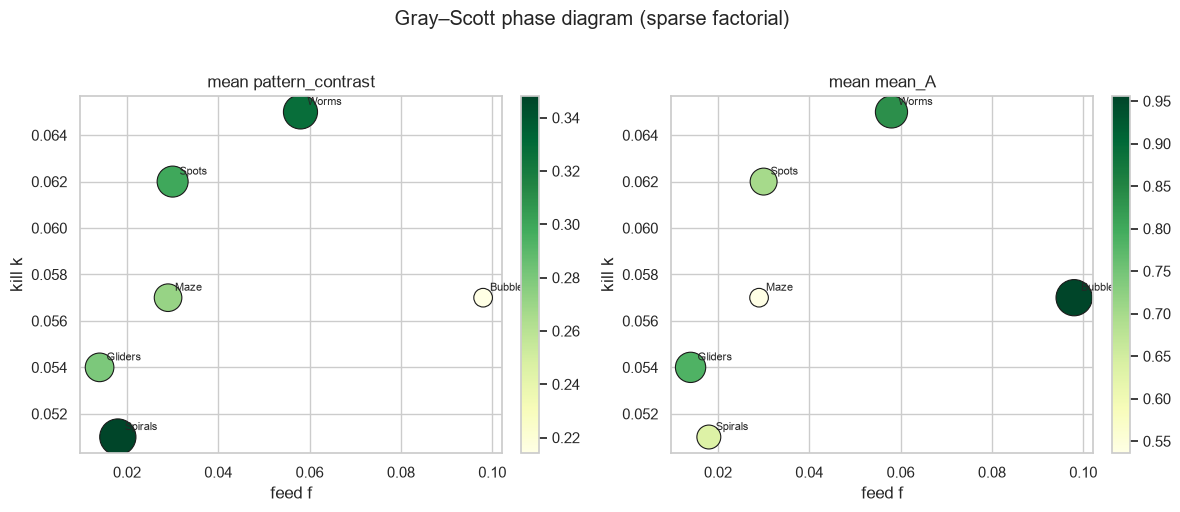

In [5]:

cell = (
    df.groupby(["f", "k", "pattern"], as_index=False)[metrics]
    .mean()
    .sort_values(["k", "f"])
)
display(cell[["pattern", "f", "k", "pattern_contrast", "mean_A", "mean_B", "spectral_slope"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, title in zip(
    axes,
    ["pattern_contrast", "mean_A"],
    ["mean pattern_contrast", "mean mean_A"],
):
    sc = ax.scatter(
        cell["f"], cell["k"],
        c=cell[metric],
        s=180 + 500 * (cell[metric] - cell[metric].min()) / ((cell[metric].max() - cell[metric].min()) + 1e-9),
        cmap="YlGn", edgecolors="k", linewidths=0.8,
    )
    for _, r in cell.iterrows():
        ax.annotate(r["pattern"], (r["f"], r["k"]), textcoords="offset points",
                    xytext=(5, 5), fontsize=8)
    ax.set_xlabel("feed f"); ax.set_ylabel("kill k"); ax.set_title(title)
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Gray–Scott phase diagram (sparse factorial)", y=1.02)
plt.tight_layout(); plt.show()


## Heatmaps on the (f, k) plane

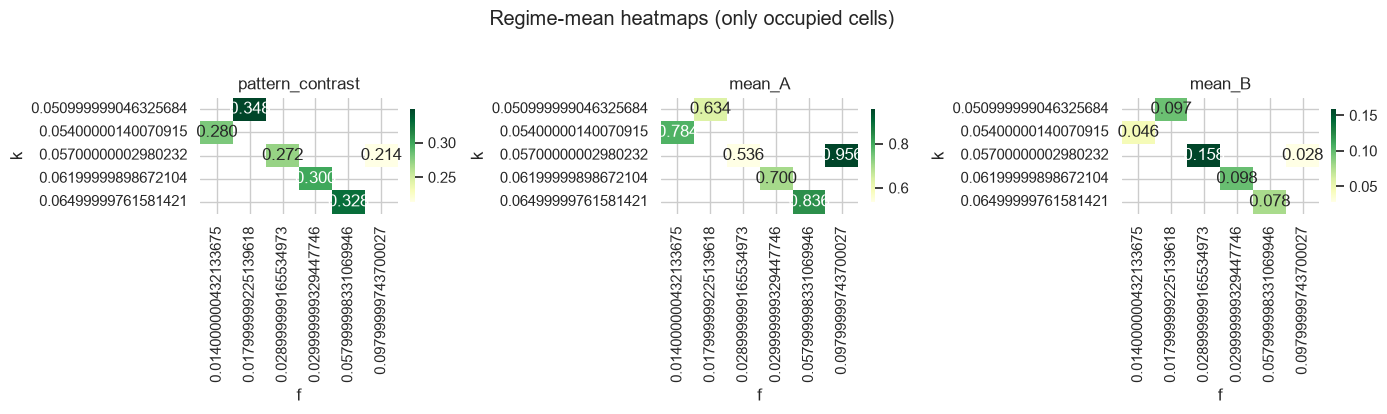

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["pattern_contrast", "mean_A", "mean_B"]):
    piv = cell.pivot(index="k", columns="f", values=metric)
    sns.heatmap(piv, annot=True, fmt=".3f", cmap="YlGn", ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(metric); ax.set_xlabel("f"); ax.set_ylabel("k")
plt.suptitle("Regime-mean heatmaps (only occupied cells)", y=1.03)
plt.tight_layout(); plt.show()


## Pattern metrics vs parameters

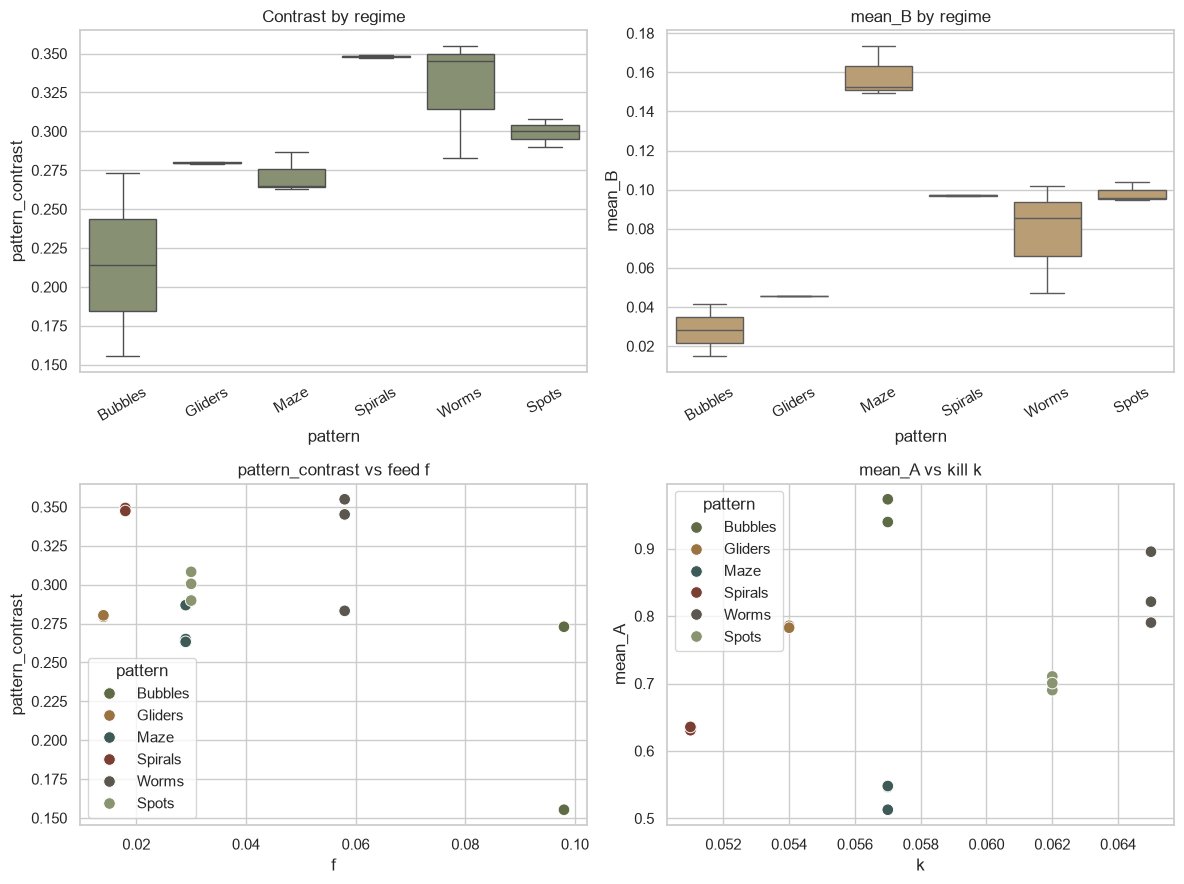

In [7]:

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.boxplot(data=df, x="pattern", y="pattern_contrast", ax=axes[0, 0], color="#8A9470")
axes[0, 0].tick_params(axis="x", rotation=30); axes[0, 0].set_title("Contrast by regime")

sns.boxplot(data=df, x="pattern", y="mean_B", ax=axes[0, 1], color="#C4A06A")
axes[0, 1].tick_params(axis="x", rotation=30); axes[0, 1].set_title("mean_B by regime")

sns.scatterplot(data=df, x="f", y="pattern_contrast", hue="pattern", s=70, ax=axes[1, 0])
axes[1, 0].set_title("pattern_contrast vs feed f")

sns.scatterplot(data=df, x="k", y="mean_A", hue="pattern", s=70, ax=axes[1, 1])
axes[1, 1].set_title("mean_A vs kill k")
plt.tight_layout(); plt.show()


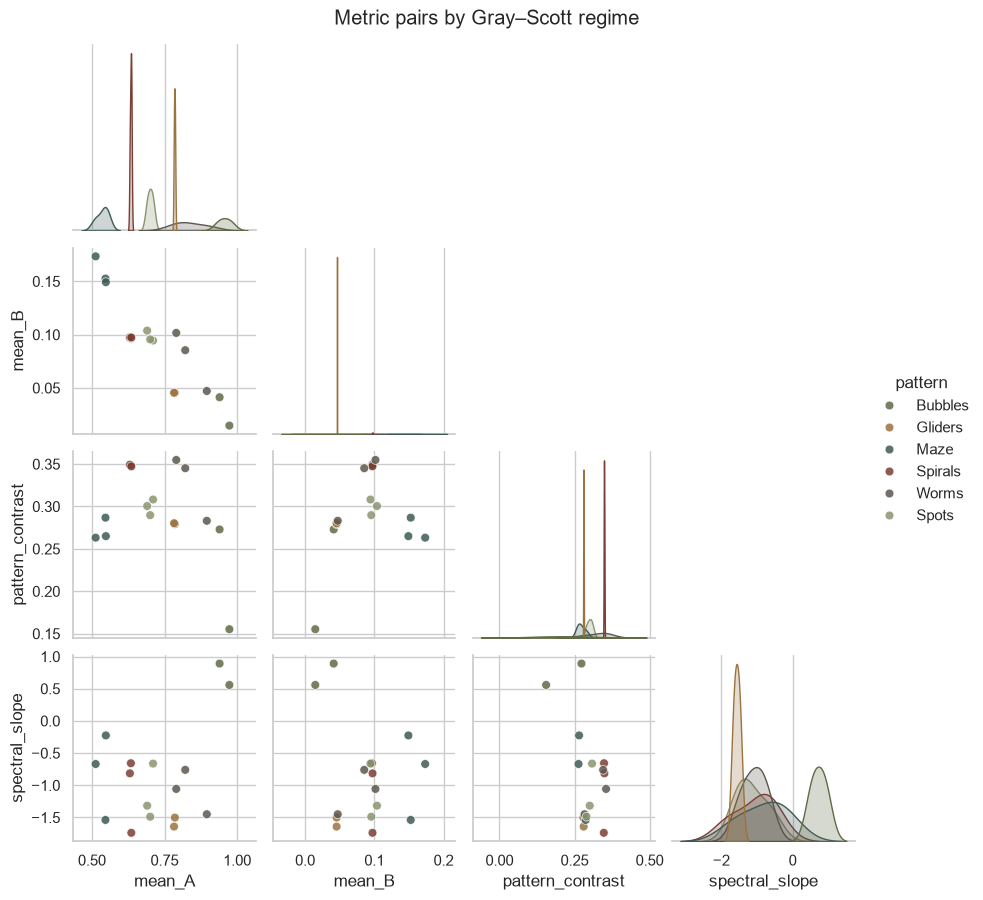

In [8]:

# Pairplot of key metrics colored by regime
pair_cols = [c for c in ["mean_A", "mean_B", "pattern_contrast", "spectral_slope"] if c in df.columns]
g = sns.pairplot(df, vars=pair_cols, hue="pattern", corner=True, height=2.2,
                 plot_kws={"s": 40, "alpha": 0.85})
g.fig.suptitle("Metric pairs by Gray–Scott regime", y=1.02)
plt.show()


## Spearman correlations

,f,k,pattern_contrast,mean_A,mean_B,std_A,std_B,spectral_slope,time_to_steady
f,1.000,0.741,-0.143,0.611,-0.253,-0.537,0.432,0.517,-0.479
k,0.741,1.000,0.020,0.415,0.002,-0.330,0.469,0.112,-0.308
pattern_contrast,-0.143,0.020,1.000,-0.126,0.250,0.868,0.662,-0.265,0.647
mean_A,0.611,0.415,-0.126,1.000,-0.853,-0.209,0.132,0.179,0.115
mean_B,-0.253,0.002,0.250,-0.853,1.000,0.150,0.168,-0.132,-0.272
std_A,-0.537,-0.330,0.868,-0.209,0.150,1.000,0.318,-0.400,0.851
std_B,0.432,0.469,0.662,0.132,0.168,0.318,1.000,0.106,0.102
spectral_slope,0.517,0.112,-0.265,0.179,-0.132,-0.400,0.106,1.000,-0.454
time_to_steady,-0.479,-0.308,0.647,0.115,-0.272,0.851,0.102,-0.454,1.000


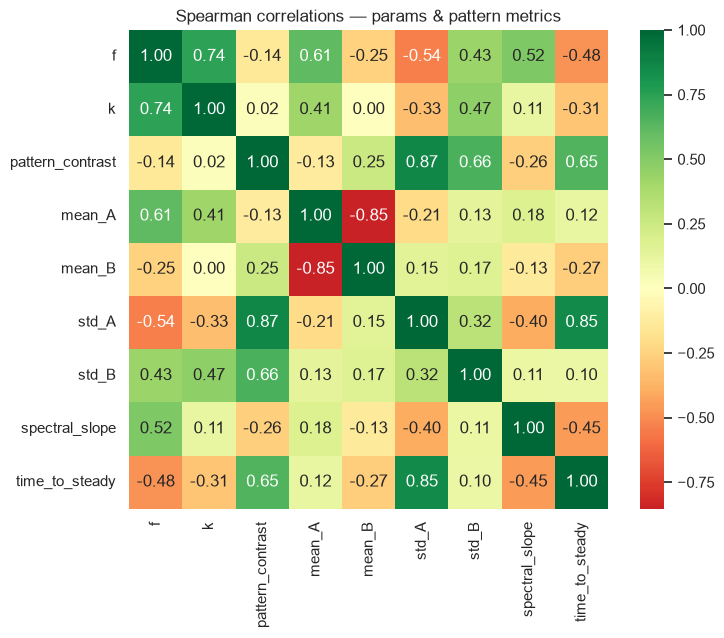

In [9]:

num = list(dict.fromkeys(c for c in ["f", "k", *metrics] if c in df.columns))
corr = df[num].corr(method="spearman")
display(corr.round(3))

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, square=True)
plt.title("Spearman correlations — params & pattern metrics")
plt.tight_layout(); plt.show()


## Ranking regimes by contrast

,n,contrast_mean,contrast_std,mean_A,mean_B,spectral_slope,f,k
pattern,,,,,,,,
Spirals,3,0.3483,0.0010,0.6335,0.0971,-1.0698,0.018,0.051
Worms,3,0.3277,0.0389,0.8357,0.0781,-1.0887,0.058,0.065
Spots,3,0.2995,0.0093,0.7004,0.0980,-1.1557,0.030,0.062
Gliders,2,0.2798,0.0007,0.7842,0.0455,-1.5712,0.014,0.054
Maze,3,0.2717,0.0131,0.5358,0.1584,-0.8109,0.029,0.057
Bubbles,2,0.2141,0.0832,0.9564,0.0280,0.7245,0.098,0.057


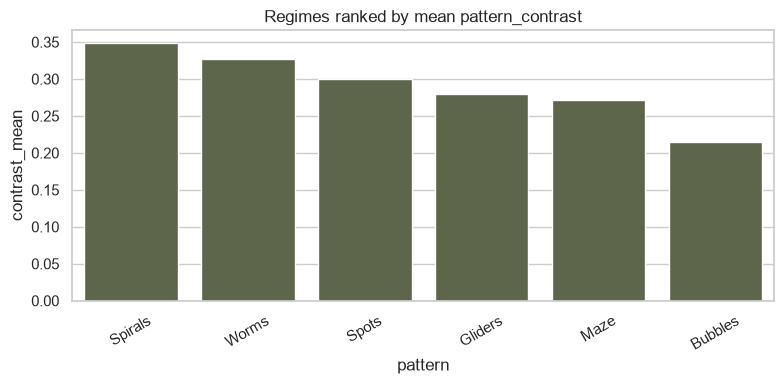

In [10]:

rank = (
    df.groupby("pattern")
    .agg(
        n=("pattern_contrast", "size"),
        contrast_mean=("pattern_contrast", "mean"),
        contrast_std=("pattern_contrast", "std"),
        mean_A=("mean_A", "mean"),
        mean_B=("mean_B", "mean"),
        spectral_slope=("spectral_slope", "mean"),
        f=("f", "first"),
        k=("k", "first"),
    )
    .sort_values("contrast_mean", ascending=False)
    .round(4)
)
display(rank)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=rank.reset_index(), x="pattern", y="contrast_mean",
            color="#5F6B45", ax=ax)
ax.set_title("Regimes ranked by mean pattern_contrast")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()


## Takeaway

Treat `(f, k)` as a **phase diagram / sparse factorial**, not a balanced ANOVA layout. Named regimes separate in contrast and concentration space; heatmaps and rankings make those separations readable at a glance.
